In [4]:
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline
# グラフプロット用基準関数
def f(x, y):
    z = x ** 2 + y ** 2
    return z
# 基準関数の微分
def df(x, y):
    dzdx = 2 * x
    dzdy = 2 * y
    dz = np.array([dzdx, dzdy])
    return dz

# 勾配降下法に必要なパラメータ
eta = 0.1                           # 学習率
max_iteration = 1000                # 最大反復回数
x0 = -10                            # 初期値x0
y0 = 10                             # 初期値y0
x_pred = [x0]                       # 描画用x0軌跡リスト(初期値をプリセット)
y_pred = [y0]                       # 描画用y0軌跡リスト(初期値をプリセット)

# 最大反復回数まで計算する
for i in range(max_iteration):
    x0, y0 = np.array([x0, y0]) - eta * df(x0, y0)          # 勾配降下法
    x_pred.append(x0)               # x0の軌跡をリストに追加
    y_pred.append(y0)               # y0の軌跡をリストに追加
    print(i, x0, y0)

x_pred = np.array(x_pred)           # 描画用にx0をnumpy配列変換
y_pred = np.array(y_pred)           # 描画用にx0をnumpy配列変換
z_pred = f(x_pred, y_pred)          # 軌跡のz値を計算

# 基準関数の表示用
x = np.arange(-10, 11, 2)
y = np.arange(-10, 11, 2)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)


# ---------------------------------------------------------------------------------

0 -8.0 8.0
1 -6.4 6.4
2 -5.12 5.12
3 -4.096 4.096
4 -3.2768 3.2768
5 -2.62144 2.62144
6 -2.0971520000000003 2.0971520000000003
7 -1.6777216000000004 1.6777216000000004
8 -1.3421772800000003 1.3421772800000003
9 -1.0737418240000003 1.0737418240000003
10 -0.8589934592000003 0.8589934592000003
11 -0.6871947673600002 0.6871947673600002
12 -0.5497558138880001 0.5497558138880001
13 -0.43980465111040007 0.43980465111040007
14 -0.35184372088832006 0.35184372088832006
15 -0.281474976710656 0.281474976710656
16 -0.22517998136852482 0.22517998136852482
17 -0.18014398509481985 0.18014398509481985
18 -0.14411518807585588 0.14411518807585588
19 -0.11529215046068471 0.11529215046068471
20 -0.09223372036854777 0.09223372036854777
21 -0.07378697629483821 0.07378697629483821
22 -0.05902958103587057 0.05902958103587057
23 -0.04722366482869646 0.04722366482869646
24 -0.037778931862957166 0.037778931862957166
25 -0.030223145490365734 0.030223145490365734
26 -0.024178516392292588 0.024178516392292588
27 -0.

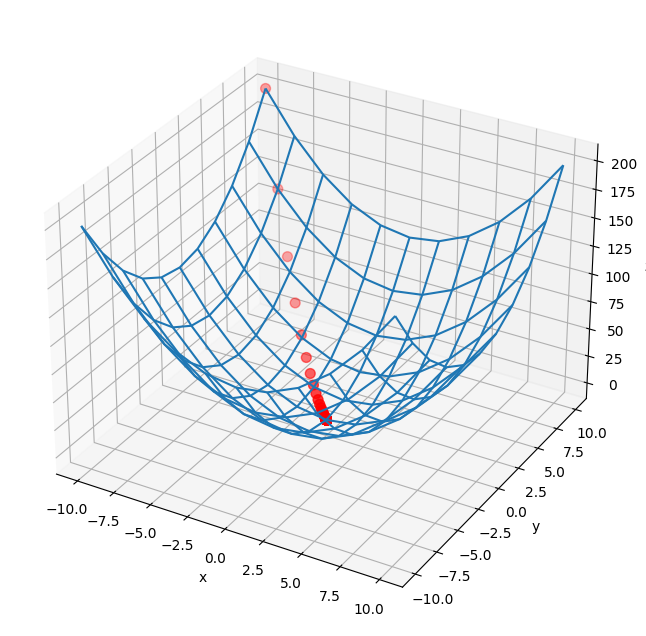

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax1 = fig.add_subplot(111, projection='3d')  # This replaces the `Axes3D(fig)` line

# Set axis labels
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')

# Plot the data
ax1.plot_wireframe(X, Y, Z, label='f(x, y)')
ax1.scatter3D(x_pred, y_pred, z_pred, label='gd', color='red', s=50)

# Display the plot
plt.show()

In [7]:
# 関数定義
def function_f(x):
    return x[0]**2 + x[1]**2
# 勾配
def numberical_gradient(f, x, h=1e-5):
    grad = np.zeros_like(x) # xと同じ形状の配列を生成
    for idx in range(x.size):
        # f(x+h)の計算
        tmp_val = x[idx]
        x[idx] = tmp_val + h
        fxh1 = f(x)
        # f(x-h)の計算
        x[idx] = tmp_val - h
        fxh2 = f(x)
        
        grad[idx] = (fxh1 - fxh2) / (2 * h)
        x[idx] = tmp_val # 値を元に戻す
    return grad

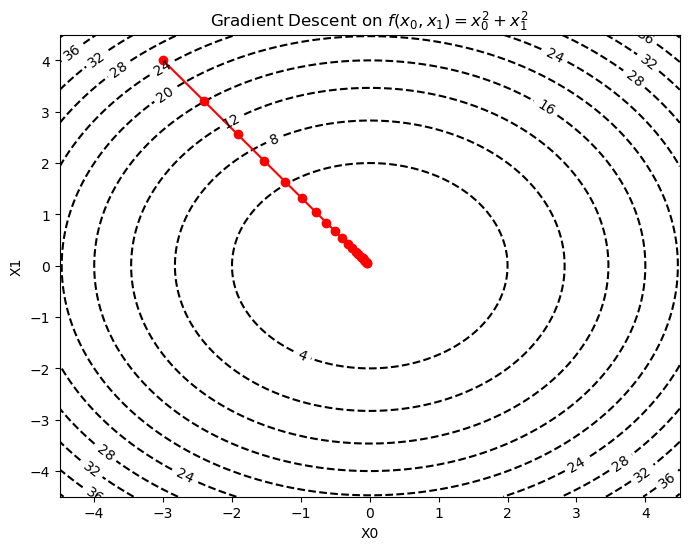

In [9]:
# Parameters
init_x = np.array([-3.0, 4.0])
lr = 0.1
num_iterations = 20

# Run gradient descent
x_history = gradient_descent(function_f, init_x, lr, num_iterations)

# 勾配降下法の実装
def gradient_descent(f, init_x, lr=0.01, num_iterations=100):
    x = init_x
    x_history = [x.copy()]

    for i in range(num_iterations):
        grad = numberical_gradient(f, x)
        x -= lr * grad
        x_history.append(x.copy())

    return np.array(x_history)

# Parameters
init_x = np.array([-3.0, 4.0])
lr = 0.1
num_iterations = 20

# 可視化
x = np.linspace(-4.5, 4.5, 200)
y = np.linspace(-4.5, 4.5, 200)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2

plt.figure(figsize=(8, 6))
contour = plt.contour(X, Y, Z, levels=10, colors='black', linestyles='dashed')
plt.clabel(contour)

plt.plot(x_history[:, 0], x_history[:, 1], 'o-', color='red')
plt.xlim(-4.5, 4.5)
plt.ylim(-4.5, 4.5)
plt.xlabel("X0")
plt.ylabel("X1")
plt.title("Gradient Descent on $f(x_0, x_1) = x_0^2 + x_1^2$")
plt.show()

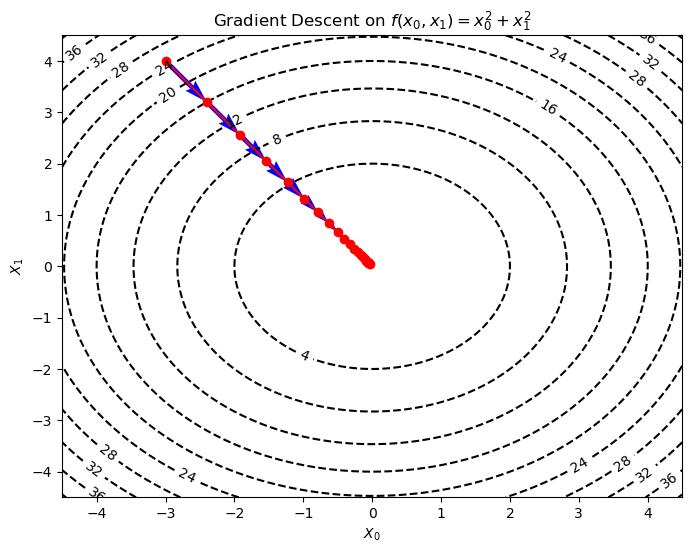

In [18]:
# Parameters
init_x = np.array([-3.0, 4.0])
lr = 0.1
num_iterations = 20

# Run gradient descent
x_history = gradient_descent(function_f, init_x, lr, num_iterations)

# 可視化
x = np.linspace(-4.5, 4.5, 200)
y = np.linspace(-4.5, 4.5, 200)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2

plt.figure(figsize=(8, 6))
contour = plt.contour(X, Y, Z, levels=10, colors='black', linestyles='dashed')
plt.clabel(contour)

# Adding arrows for each gradient
for i in range(1, len(x_history)):
    plt.quiver(x_history[i-1][0], x_history[i-1][1], 
               x_history[i][0]-x_history[i-1][0], 
               x_history[i][1]-x_history[i-1][1], 
               angles="xy", scale_units="xy", scale=1, color="blue")

plt.plot(x_history[:, 0], x_history[:, 1], 'o-', color='red')
plt.xlim(-4.5, 4.5)
plt.ylim(-4.5, 4.5)
plt.xlabel("$X_0$")
plt.ylabel("$X_1$")
plt.title("Gradient Descent on $f(x_0, x_1) = x_0^2 + x_1^2$")
plt.show()